## Import the necessary tools and assemblies

In [1]:
import duckdb
import os
import pandas as pd
import re

from dotenv import load_dotenv
from pathlib import Path
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
from typing import Annotated, TypedDict, Sequence, Optional, Dict, Any, Type, List
from datetime import date, datetime, time
from dataclasses import asdict
import json

## Load the.env file

In [2]:
load_dotenv()

True

## Let's define some constants

In [3]:
SYSTEM_PROMPT = """
You are a concise conversational data assistant for a DuckDB hospital database that contains sensitive and personal information.

Rules:
- If a user asks a question that requires database data, call the run_sql tool with the SQL query that you will build.
- Use sql toolset that are specific for the entities, if that doesnt satisfy the request, use the get_schema to identify the necessary tables and columns
- If you are unsure what tables/columns exist, call get_schema first.
- Use ONLY the tool results to answer data questions; do not fabricate numbers.
- Keep responses brief and conversational.
- Avoid multiple SQL statements and do not end with semi-colon.
- Use explicit joins.
- Adhere to ANSI-SQL standards.
"""

_SQL_DISALLOWED = re.compile(
    r"\b(INSERT|UPDATE|DELETE|DROP|ALTER|CREATE|ATTACH|DETACH|COPY|EXPORT|IMPORT|PRAGMA)\b",
    re.IGNORECASE,
)

## Verify db path

In [4]:
DB_PATH = Path("../../garvis-backend/data/garvis.duckdb").resolve()   # <-- change if needed

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB file not found at {DB_PATH}. "
        "Run your one-time creation script first."
    )

print("Using DB:", DB_PATH)

Using DB: /media/SN850X-A/vscode/kaggle/garvis/garvis-backend/data/garvis.duckdb


## Let's instantiate an MeGemma through ollama 

In [5]:
llm_ollama = ChatOllama(
    model="MedAIBase/MedGemma1.5:4b"
    ,validate_model_on_init=True
    ,temperature=0
)

## Let's declare some helper methods

In [6]:
def _connect_db(db_path: Path) -> duckdb.DuckDBPyConnection:
    return duckdb.connect(str(db_path))

def _sanitize_sql(sql: str) -> str:
    sql = (sql or "").strip().strip("`")
    sql = re.sub(r"^```(sql)?\s*|\s*```$", "", sql, flags=re.IGNORECASE).strip()
    
    # block multi-statements
    if(";" in sql):
        raise ValueError("Only a single SQL statement is allowed (no semicolons).")

    if(_SQL_DISALLOWED.search(sql)):
        raise ValueError("Only read-only queries are allowed (SELECT / WITH).")

    if(not re.match(r"^(SELECT|WITH)\b", sql, flags=re.IGNORECASE)):
        raise ValueError("Query must start with SELECT or WITH.")

    # keep results manageable
    if(not re.search(r"\bLIMIT\b", sql, flags=re.IGNORECASE)):
        sql = f"{sql}\nLIMIT 200"
    return sql

def _schema_markdown(conn: duckdb.DuckDBPyConnection) -> str:
    tables = [r[0] for r in conn.execute("SHOW TABLES").fetchall()]
    if(not tables):
        return "(no tables found)"
    out = []
    for t in tables:
        cols = conn.execute(f"DESCRIBE {t}").fetchall()
        out.append(f"### {t}")
        for c in cols:
            out.append(f"- {c[0]}: {c[1]}")
        out.append("")
    return "\n".join(out).strip()

## Let's declare some @tools that our orchestrating LLM can utilize

In [7]:
@tool
def get_schema() -> str:
    """Return the DuckDB schema information (tables and columns) in a compact format."""
    con = _connect_db(DB_PATH)
    try:
        database_markdown = _schema_markdown(con)
    finally:
        con.close()        
    
    return database_markdown

@tool
def run_sql(query: str) -> str:
    """
    Execute a read-only SQL query (SELECT/WITH) against DuckDB and return results as markdown.
    """
    sql = _sanitize_sql(query)
    
    con = _connect_db(DB_PATH)
    try:
        df = con.execute(sql).df()
    finally:
        con.close()        
    
    #print(f"****************\n\n{query}\n\n****************")

    if df.empty:
        return f"SQL:\n{sql}\n\nResult: (no rows)"
    return f"SQL:\n{sql}\n\nResult:\n{df.to_markdown(index=False)}"

#@tool
#def determine_action(query: str) -> str:
#    """
#    This tool analyzes the previous data that you've garnered, and based on the data from the queries that you've received, i want you to output a simple standard-json output defining the next set of steps with the data. 
#    
#    
#    1. If the user or doctor request starts with SHOW ME CALENDAR, something like "SHOW ME CALENDAR" or "SHOW ME SCHEDULE OF DOCTOR..." or something similar, query the requested doctor's name and output this json-compliant data enclosed in triple backticks example:```{"action":"calendar","doctor_id":1, "date": "2025-11-16T07:48:47.748880"}```
#    2. If the user or doctor request starts with SHOW ME PATIENT FILE, something like "SHOW ME patient file of..." or something contextually similar, query the requested patient's data and output this json-compliant data enclosed in triple backticks example:```{"action":"patient_file","patient_id":1}```
#    3. If the user or doctor request starts with SHOW ME MEDICAL HISTORY, something like "SHOW ME patient's medical history" or "get history of patient..." or something contextually similar, query the requested patient's and output this json-compliant data enclosed in triple backticks example:```{"action":"patient_history","patient_id":2}```
#    4. If the user or doctor request starts with SHOW ME that is not one of the three items above, output this json-compliant data enclosed in triple backticks example:```{"action":"none","feedback":"unknown request"}```
#    """
#    resp = llm.invoke([
#        SystemMessage(content="""Based on the data from the queries that you've received, i want you to output a simple standard-json output defining the next set of steps with the data. 
#    
#    
#    1. If the user or doctor request starts with SHOW ME CALENDAR, something like "SHOW ME CALENDAR" or "SHOW ME SCHEDULE OF DOCTOR..." or something similar, query the requested doctor's name and output this json-compliant data enclosed in triple backticks example:```{"action":"calendar","doctor_id":1, "date": "2025-11-16T07:48:47.748880"}```
#    2. If the user or doctor request starts with SHOW ME PATIENT FILE, something like "SHOW ME patient file of..." or something contextually similar, query the requested patient's data and output this json-compliant data enclosed in triple backticks example:```{"action":"patient_file","patient_id":1}```
#    3. If the user or doctor request starts with SHOW ME MEDICAL HISTORY, something like "SHOW ME patient's medical history" or "get history of patient..." or something contextually similar, query the requested patient's and output this json-compliant data enclosed in triple backticks example:```{"action":"patient_history","patient_id":2}```
#    4. If the user or doctor request starts with SHOW ME that is not one of the three items above, output this json-compliant data enclosed in triple backticks example:```{"action":"none","feedback":"unknown request"}```
#    
#    """
#                     ),HumanMessage(content=query)])
#    return resp.content       


@tool
def medgemma_reasoner(task: str) -> str:
    """
    Use the Med Gemma model for medical-related inquiries, like asking what disease or ailment shows certain symptoms.
    Or in cases where for certain situations, what is the first aid
    """
    resp = llm_ollama.invoke([
        SystemMessage(content="""You are an amazing AI-assistant that specializes in medical and health-related inquiries.
                      For every inquiry I give you, answer to the best of your capabilities, and always cite your sources 
                      and state how confident are you from LOW, MEDIUM, and HIGH!"""
                     ),HumanMessage(content=task)])
    return resp.content

## Let's declare another set of helper methods

In [8]:
def _json_safe(v: Any) -> Any:
    if isinstance(v, datetime):
        return v.isoformat()
    if isinstance(v, date):
        return v.isoformat()
    if isinstance(v, time):
        return v.isoformat()
    if isinstance(v, dict):
        return {k: _json_safe(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)):
        return [_json_safe(x) for x in v]
    return v

def _fetchone_dict(
    con: duckdb.DuckDBPyConnection, sql: str, params: Optional[tuple] = None
) -> Optional[Dict[str, Any]]:
    """
    Return one row as {column: value} or None.
    """
    cur = con.execute(sql, params or ())
    row = cur.fetchone()
    if row is None:
        return None
    cols = [d[0] for d in cur.description]
    return json.dumps(dict(zip(cols, row)), default=_json_safe, ensure_ascii=False)

def _fetchall_dicts(
    con: duckdb.DuckDBPyConnection, sql: str, params: Optional[tuple] = None
) -> List[Dict[str, Any]]:
    """
    Return all rows as [{column: value}, ...].
    """
    cur = con.execute(sql, params or ())
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description]

    return json.dumps([dict(zip(cols, r)) for r in rows], default=_json_safe, ensure_ascii=False)

## Again define some tools

In [9]:
@tool
def get_patient_by_full_name(
    first_name: str, last_name: str
) -> Optional[Dict[str, Any]]:
    """Query the duckduckdb for the patients using either first name or last name as the parameter."""
    with _connect_db(DB_PATH) as con:
        row = _fetchone_dict(
            con,
            """
            SELECT *
            FROM patient
            WHERE lower(first_name) = lower(?) AND lower(last_name) = lower(?)
            """,
            (first_name, last_name),
    )

    return row if row else None

@tool
def get_patient_full_history(patient_id: int) -> Optional[List[Dict[str, Any]]]:
    """Query the duckduckdb for a patient's full medical history contained in the patient_history table using patient_id as the parameter.
       Only query this table when explicitly instructed.
    """
    with _connect_db(DB_PATH) as con:
        rows = _fetchall_dicts(
            con,
            """
            SELECT *
            FROM patient_history
            WHERE patient_id = ?
            ORDER BY event_start_at DESC
            """,
            (patient_id,),
        )
        return rows if rows else None

## In case we need to test, read comment and uncoment print line

In [10]:
# remove tool decorator to test it
#print(get_patient_by_full_name("Danielle","Garcia"))

In [11]:
# remove tool decorator to test it
#print(get_patient_full_history(1))

## Let's create a list of our tools that our LLM can utilize

In [12]:
tools = [get_schema
         , run_sql
         , medgemma_reasoner
         , DuckDuckGoSearchRun()
         , get_patient_by_full_name
         , get_patient_full_history
         #, determine_action
        ]

## Bind the tools

In [13]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(tools)

In [14]:
from typing import Literal, Dict, Any
from pydantic import BaseModel, Field
class Route(BaseModel):
    view: Literal["none", "calendar", "patient_file", "patient_history"]
    action: Literal["drilldown"]
    params: Dict[str, Any] = Field(default_factory=dict)

In [15]:
ROUTER_SYSTEM = (
    "You are a UI router. Output ONLY the routing object that matches the schema. "
    "Do not include any additional keys or text."
)

In [16]:
class AgentState(TypedDict, total=False):
    messages:Annotated[Sequence[BaseMessage], add_messages]
    route: str

In [17]:
def router_node(state: AgentState):
    user_text = state["messages"][-1].content
    route: Route = router_llm.invoke([
        {"role": "system", "content": ROUTER_SYSTEM},
        {"role": "user", "content": f"Decide route for:\n{user_text}"}
    ])
    # store as plain dict in state
    print(route.model_dump())
    print(route.json)
    state["route"] = route.model_dump()
    return state

In [18]:
router_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(Route)

## Let's create the agentstate

In [19]:


def assistant_node(state: AgentState) -> AgentState:
    response = llm.invoke([SystemMessage(content=SYSTEM_PROMPT)] + state["messages"])
    state["messages"] = state["messages"] + [response]
    return state

def should_continue(state: AgentState)->str:
    state_messages = state["messages"] #copies the latest state into the "messages" variable
    last_message = state_messages[-1] #get only the last message
    
    # one or more branching logic
    if(not last_message.tool_calls):
        return "route_selector"
    else:
        return "tools"
    
def route_selector(state: AgentState)->str:
    state["route"] = state["route"]
    return state


## Let's create the graph

In [20]:
checkpointer = InMemorySaver()
builder = StateGraph(AgentState)
builder.add_node("assistant", assistant_node)
builder.add_node("tools", ToolNode(tools))
builder.add_node("route_selector",route_selector)
builder.add_edge(START, "assistant")
#we will map the edge here to one or more destinations
builder.add_conditional_edges("assistant", should_continue, {"tools": "tools", "route_selector": "route_selector"})
builder.add_edge("tools", "assistant")
builder.add_edge("route_selector", END)
graph = builder.compile(checkpointer=checkpointer)

## Let's visualize the graph

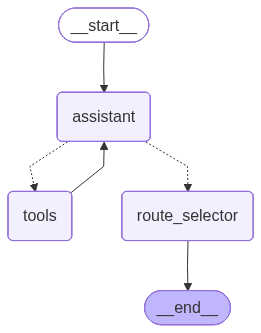

In [21]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Helper method so that we can chat to our graph

In [22]:
def chat(user_text: str, thread_id: str = "demo", display_tool_call:bool=False) -> str:
    cfg = {"configurable": {"thread_id": thread_id}}
    final_state = graph.invoke({"messages": [HumanMessage(content=user_text)],"route":{"view":"none"}}, config=cfg)
    
    if(display_tool_call):
        for msg in final_state["messages"]:
            if(hasattr(msg,"tool_calls")):
                for index, tool_call in enumerate(msg.tool_calls):
                    print("*"*100)
                    print(f"Tool Call: #{index+1}| Name: {tool_call["name"]}| Args: {tool_call["args"]}")    
    
    print(final_state["messages"][-1].content, final_state["route"])
    
    # The latest assistant message is at the end
    return final_state["messages"][-1].content

## Let's chat to our LLM

In [23]:
print(chat("What tables do we have?", thread_id="sales-thread"))

We have the following tables in the database:

1. **calendar**
2. **doctor**
3. **patient**
4. **patient_history**
5. **xray** 

Let me know if you need more information about any specific table! {'view': 'none'}
We have the following tables in the database:

1. **calendar**
2. **doctor**
3. **patient**
4. **patient_history**
5. **xray** 

Let me know if you need more information about any specific table!


In [24]:
yyy = chat("""SHOW ME Angel Jennings's medical history""", thread_id="sales-thread")

print(yyy)

Here’s the medical history for Angel Jennings:

1. **Prescription**  
   - **Date:** 2025-10-10  
   - **Chief Complaint:** Abdominal pain  
   - **Diagnosis:** Muscle strain  
   - **Prescription:** Azithromycin  
   - **Outcome:** Ongoing  
   - **Follow-up Required:** No  

2. **Emergency**  
   - **Date:** 2021-10-20  
   - **Chief Complaint:** Dizziness  
   - **Diagnosis:** Migraine  
   - **Procedure:** IV fluids  
   - **Prescription:** Prednisone  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

3. **Consultation**  
   - **Date:** 2021-10-18  
   - **Chief Complaint:** Abdominal pain  
   - **Diagnosis:** Migraine  
   - **Prescription:** Amoxicillin; Ondansetron  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

4. **Consultation**  
   - **Date:** 2021-02-19  
   - **Chief Complaint:** Sore throat  
   - **Diagnosis:** Asthma exacerbation  
   - **Prescription:** Ibuprofen  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

5.

In [25]:
print(chat("Get me a list of the patients with their ids, first names and last names?", thread_id="sales-thread"))

Here’s a list of patients with their IDs, first names, and last names:

| Patient ID | First Name  | Last Name   |
|------------|-------------|-------------|
| 1          | Danielle    | Garcia      |
| 2          | Angel       | Jennings    |
| 3          | Joshua      | Stephens    |
| 4          | Jeffrey     | Levine      |
| 5          | Jill        | Howard      |
| 6          | Erica       | Sanders     |
| 7          | Patricia    | Lopez       |
| 8          | Christopher | Martinez    |
| 9          | Robert      | Charles     |
| 10         | Anthony     | Gibson      |
| ...        | ...         | ...         |
| 200        | Mary        | Davis       |

Let me know if you need more details or a specific range! {'view': 'none'}
Here’s a list of patients with their IDs, first names, and last names:

| Patient ID | First Name  | Last Name   |
|------------|-------------|-------------|
| 1          | Danielle    | Garcia      |
| 2          | Angel       | Jennings    |
| 3   

In [26]:
xxx = chat("""Get me all the details of Danielle Garcia patient, do not include medical history.""", thread_id="sales-thread")
print(xxx)

Here are the details for patient Danielle Garcia:

- **Patient ID:** 1
- **Created At:** 2026-01-17
- **First Name:** Danielle
- **Last Name:** Garcia
- **Sex:** Male
- **Date of Birth:** 1929-01-05
- **Deceased Flag:** No
- **Marital Status:** Married
- **Language:** French
- **Email:** valerieboyd@example.com
- **Phone:** 477-731-8063
- **Address:** 517 Bryant Squares Apt. 274, Ellisonchester, USA, 19797
- **Organization ID:** 380
- **Insurance Plan ID:** 165
- **Active Flag:** Yes
- **Last Seen At:** 2021-01-14
- **Height (cm):** 179.63
- **Weight (kg):** 56.11
- **BMI:** 17.39
- **Alcohol Use:** Social
- **Has Asthma:** Yes
- **Has Diabetes:** No
- **Has Hypertension:** No
- **Has COPD:** No
- **Has CKD:** No

If you need anything else, just let me know! {'view': 'none'}
Here are the details for patient Danielle Garcia:

- **Patient ID:** 1
- **Created At:** 2026-01-17
- **First Name:** Danielle
- **Last Name:** Garcia
- **Sex:** Male
- **Date of Birth:** 1929-01-05
- **Deceased Fl

In [27]:
xxx = chat("""Show me patient history of Danielle Garcia""", thread_id="sales-thread")
print(xxx)

Here’s the patient history for Danielle Garcia:

1. **Prescription**  
   - **Date:** 2025-11-16  
   - **Chief Complaint:** Sore throat  
   - **Diagnosis:** Hypertension  
   - **Prescription:** Metformin  
   - **Outcome:** Resolved  
   - **Follow-up Required:** No  

2. **Diagnostic Test**  
   - **Date:** 2025-04-27  
   - **Chief Complaint:** Rash  
   - **Diagnosis:** Gastroenteritis  
   - **Procedure:** CT scan  
   - **Outcome:** Resolved  
   - **Follow-up Required:** No  

3. **Consultation**  
   - **Date:** 2024-05-20  
   - **Chief Complaint:** Urinary pain  
   - **Diagnosis:** Urinary tract infection  
   - **Prescription:** Ondansetron  
   - **Outcome:** Resolved  
   - **Follow-up Required:** No  

4. **Surgery**  
   - **Date:** 2024-01-14  
   - **Chief Complaint:** Fever  
   - **Diagnosis:** Viral infection  
   - **Procedure:** Vaccination  
   - **Outcome:** Ongoing  
   - **Follow-up Required:** No  

5. **Consultation**  
   - **Date:** 2023-03-16  
   - **

In [28]:
xxx = chat("""Get me all the details of Danielle Garcia patient, do not include medical history. Output it as is and output the tool reply straight""", thread_id="sales-thread")
print(xxx)

{"patient_id": 1, "created_at": "2026-01-17T23:38:47.192729+08:00", "first_name": "Danielle", "last_name": "Garcia", "sex": "male", "date_of_birth": "1929-01-05T00:00:00", "deceased_flag": false, "marital_status": "married", "language": "French", "email": "valerieboyd@example.com", "phone": "477-731-8063", "address_line1": "517 Bryant Squares Apt. 274", "address_line2": null, "city": "Ellisonchester", "state": null, "postal_code": "19797", "country": "USA", "primary_care_provider_id": null, "organization_id": 380, "insurance_plan_id": 165, "active_flag": true, "last_seen_at": "2021-01-14T00:00:00", "height_cm": 179.63, "weight_kg": 56.11, "bmi": 17.39, "smoking_status": null, "alcohol_use": "social", "pregnancy_status": null, "has_diabetes": false, "has_hypertension": false, "has_copd": false, "has_ckd": false, "has_asthma": true, "updated_at": "2026-01-17T23:38:47.641555+08:00"} {'view': 'none'}
{"patient_id": 1, "created_at": "2026-01-17T23:38:47.192729+08:00", "first_name": "Daniell

In [29]:
yyy = chat("""Get me all the details of Danielle Garcia patient, do not include medical history.""", thread_id="sales-thread")

print(yyy)

Here are the details for patient Danielle Garcia:

- **Patient ID:** 1
- **Created At:** 2026-01-17
- **First Name:** Danielle
- **Last Name:** Garcia
- **Sex:** Male
- **Date of Birth:** 1929-01-05
- **Deceased Flag:** No
- **Marital Status:** Married
- **Language:** French
- **Email:** valerieboyd@example.com
- **Phone:** 477-731-8063
- **Address:** 517 Bryant Squares Apt. 274, Ellisonchester, USA, 19797
- **Organization ID:** 380
- **Insurance Plan ID:** 165
- **Active Flag:** Yes
- **Last Seen At:** 2021-01-14
- **Height (cm):** 179.63
- **Weight (kg):** 56.11
- **BMI:** 17.39
- **Alcohol Use:** Social
- **Has Asthma:** Yes
- **Has Diabetes:** No
- **Has Hypertension:** No
- **Has COPD:** No
- **Has CKD:** No

If you need anything else, just let me know! {'view': 'none'}
Here are the details for patient Danielle Garcia:

- **Patient ID:** 1
- **Created At:** 2026-01-17
- **First Name:** Danielle
- **Last Name:** Garcia
- **Sex:** Male
- **Date of Birth:** 1929-01-05
- **Deceased Fl

In [30]:
yyy = chat("""get me all the medical history of Angel Jennings patient.""", thread_id="sales-thread")

print(yyy)

Here’s the medical history for Angel Jennings:

1. **Prescription**  
   - **Date:** 2025-10-10  
   - **Chief Complaint:** Abdominal pain  
   - **Diagnosis:** Muscle strain  
   - **Prescription:** Azithromycin  
   - **Outcome:** Ongoing  
   - **Follow-up Required:** No  

2. **Emergency**  
   - **Date:** 2021-10-20  
   - **Chief Complaint:** Dizziness  
   - **Diagnosis:** Migraine  
   - **Procedure:** IV fluids  
   - **Prescription:** Prednisone  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

3. **Consultation**  
   - **Date:** 2021-10-18  
   - **Chief Complaint:** Abdominal pain  
   - **Diagnosis:** Migraine  
   - **Prescription:** Amoxicillin; Ondansetron  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

4. **Consultation**  
   - **Date:** 2021-02-19  
   - **Chief Complaint:** Sore throat  
   - **Diagnosis:** Asthma exacerbation  
   - **Prescription:** Ibuprofen  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

5.

In [31]:
yyy = chat("""get me all the medical history of Angel Jennings patient. Output the reply as is and enclose it within triple backticks""", thread_id="sales-thread")

print(yyy)

```
[{"history_id": 6055, "patient_id": 2, "doctor_id": 7, "event_type": "prescription", "event_start_at": "2025-10-10T11:26:47.748880", "event_end_at": "2025-10-10T12:10:47.748880", "chief_complaint": "abdominal pain", "diagnosis_summary": "muscle strain", "procedure_performed": null, "prescription_given": "azithromycin", "notes": "- Chief complaint: abdominal pain.\n- Assessment: muscle strain. Severity: high.\n- Prescribed: azithromycin.\n- No follow-up required unless symptoms worsen.\n- Patient education provided; return precautions discussed.", "outcome": "ongoing", "follow_up_required": false, "severity": "high", "created_at": "2026-01-17T23:38:48.094472+08:00"}, {"history_id": 3534, "patient_id": 2, "doctor_id": 70, "event_type": "emergency", "event_start_at": "2021-10-20T04:30:47.748880", "event_end_at": "2021-10-20T08:51:47.748880", "chief_complaint": "dizziness", "diagnosis_summary": "migraine", "procedure_performed": "IV fluids", "prescription_given": "prednisone", "notes":

In [32]:
yyy = chat("""SHOW ME Angel Jennings's medical history""", thread_id="sales-thread", display_tool_call=True) 

print(yyy)

****************************************************************************************************
Tool Call: #1| Name: get_schema| Args: {}
****************************************************************************************************
Tool Call: #1| Name: get_patient_by_full_name| Args: {'first_name': 'Angel', 'last_name': 'Jennings'}
****************************************************************************************************
Tool Call: #1| Name: get_patient_full_history| Args: {'patient_id': 2}
****************************************************************************************************
Tool Call: #1| Name: run_sql| Args: {'query': 'SELECT patient_id, first_name, last_name FROM patient'}
****************************************************************************************************
Tool Call: #1| Name: get_patient_by_full_name| Args: {'first_name': 'Danielle', 'last_name': 'Garcia'}
**************************************************************************

In [33]:
yyy = chat("""SHOW ME Angel Jennings's medical history""", thread_id="sales-thread")

print(yyy)

Here’s the medical history for Angel Jennings:

1. **Prescription**  
   - **Date:** 2025-10-10  
   - **Chief Complaint:** Abdominal pain  
   - **Diagnosis:** Muscle strain  
   - **Prescription:** Azithromycin  
   - **Outcome:** Ongoing  
   - **Follow-up Required:** No  

2. **Emergency**  
   - **Date:** 2021-10-20  
   - **Chief Complaint:** Dizziness  
   - **Diagnosis:** Migraine  
   - **Procedure:** IV fluids  
   - **Prescription:** Prednisone  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

3. **Consultation**  
   - **Date:** 2021-10-18  
   - **Chief Complaint:** Abdominal pain  
   - **Diagnosis:** Migraine  
   - **Prescription:** Amoxicillin; Ondansetron  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

4. **Consultation**  
   - **Date:** 2021-02-19  
   - **Chief Complaint:** Sore throat  
   - **Diagnosis:** Asthma exacerbation  
   - **Prescription:** Ibuprofen  
   - **Outcome:** Resolved  
   - **Follow-up Required:** Yes  

5.

In [35]:
yyy = chat("""Calendar view pass doctor_id """, thread_id="sales-thread", display_tool_call=True)

print(yyy)

KeyboardInterrupt: 

In [38]:
Route

__main__.Route

In [37]:
router_llm.invoke([
        {"role": "system", "content": ROUTER_SYSTEM},
        {"role": "user", "content": f"Decide route for:\n{"TEST"}"}
])

/home/bwandowando/anaconda3/envs/langgraph-lab/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:472: UserWarning: Invalid schema for OpenAI's structured output feature, which is the default method for `with_structured_output` as of langchain-openai==0.3. Specify `method="function_calling"` instead or update your schema. See supported schemas: https://platform.openai.com/docs/guides/structured-outputs#supported-schemas
  warnings.warn(message)


BadRequestError: Error code: 400 - {'error': {'message': "Invalid schema for response_format 'Route': In context=('properties', 'params'), 'additionalProperties' is required to be supplied and to be false.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': None}}